In [1]:
import numpy as np
import pandas as pd
from statsmodels.regression.linear_model import OLS
from statsmodels.tools import add_constant
from itertools import combinations

In [2]:
Na = pd.read_csv(r'C:\Users\OJH\OneDrive\SKKU\연구자료\Catalyst AI\Database\Na_Cat_1.csv')
Na.head()

,Promotor,Preparation,"Temperature, K",p(CH4)/p(O2),"p total, bar","Contact time, s","X(O2), %","X(CH4), %","S(COx), %","S(C2=), %",...,Sm_S_mol%,Tb_S_mol%,Dy_S_mol%,Yb_S_mol%,Ca_S_mol%,Zr_S_mol%,Fe_S_mol%,Sr_S_mol%,Ti_S_mol%,Sn_S_mol%
0,0,Impregnation,1017,8.0,1.0,0.19,39.0,3.0,0.0,23.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
1,0,Impregnation,1021,8.0,1.0,0.16,98.0,16.0,0.0,24.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
2,0,Impregnation,1023,8.1,1.0,38.40,97.0,15.0,0.0,25.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
3,0,Impregnation,1018,8.1,1.0,0.25,92.0,16.0,0.0,26.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
4,0,Impregnation,1016,9.6,1.0,0.49,98.0,13.0,0.0,20.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0


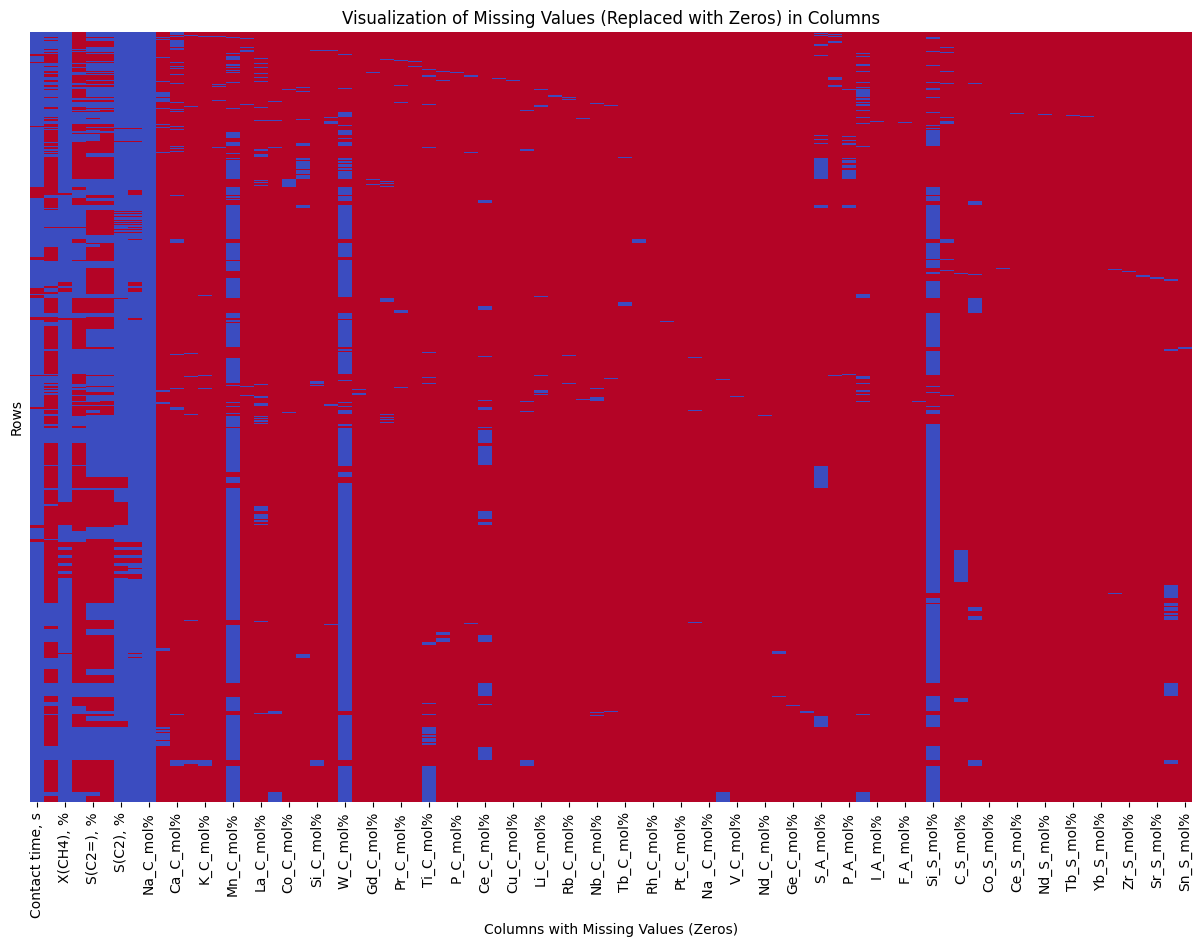

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

missing_value_columns = Na.columns[Na.eq(0).any()].tolist()

# Creating a DataFrame to visualize the presence of zeros in these columns
visualization_df = Na[missing_value_columns].eq(0).astype(int)

plt.figure(figsize=(15, 10))
sns.heatmap(visualization_df, cmap='coolwarm', cbar=False, yticklabels=False)
plt.title("Visualization of Missing Values (Replaced with Zeros) in Columns")
plt.xlabel("Columns with Missing Values (Zeros)")
plt.ylabel("Rows")
plt.show()

In [4]:
non_missing_value_columns = Na.columns[~Na.eq(0).any()].tolist()

non_missing_value_columns

['Promotor', 'Preparation', 'Temperature, K', 'p(CH4)/p(O2)', 'p total, bar']

In [5]:
Na = Na[Na['Na_C_mol%'] != 0]

In [6]:
# Finding the row indices where 'Na_C_mol%' column has missing values (replaced with zeros)
missing_value_indices = Na.index[Na['Na_C_mol%'] == 0].tolist()

missing_value_indices

[]

In [7]:
non_missing_value_columns = Na.columns[~Na.eq(0).any()].tolist()

non_missing_value_columns

['Promotor',
 'Preparation',
 'Temperature, K',
 'p(CH4)/p(O2)',
 'p total, bar',
 'Na_C_mol%']

In [8]:
Na = pd.get_dummies(Na, columns=['Preparation'], prefix=['Preparation'])
Na = pd.get_dummies(Na, columns=['Promotor'], prefix=['Promotor'])

Na.head()

,"Temperature, K",p(CH4)/p(O2),"p total, bar","Contact time, s","X(O2), %","X(CH4), %","S(COx), %","S(C2=), %","S(C2-), %","S(C2), %",...,Preparation_Slurry,Preparation_Sol-gel,Preparation_Solid-phase technique,Preparation_Therm.decomp.,Preparation_n.a.,Promotor_0,Promotor_B,Promotor_Cl,Promotor_Cl_B,Promotor_P
0,1017,8.0,1.0,0.19,39.0,3.0,0.0,23.0,19.0,42.0,...,0,0,0,0,0,1,0,0,0,0
1,1021,8.0,1.0,0.16,98.0,16.0,0.0,24.0,39.0,63.0,...,0,0,0,0,0,1,0,0,0,0
2,1023,8.1,1.0,38.40,97.0,15.0,0.0,25.0,44.0,69.0,...,0,0,0,0,0,1,0,0,0,0
3,1018,8.1,1.0,0.25,92.0,16.0,0.0,26.0,45.0,71.0,...,0,0,0,0,0,1,0,0,0,0
4,1016,9.6,1.0,0.49,98.0,13.0,0.0,20.0,41.0,61.0,...,0,0,0,0,0,1,0,0,0,0


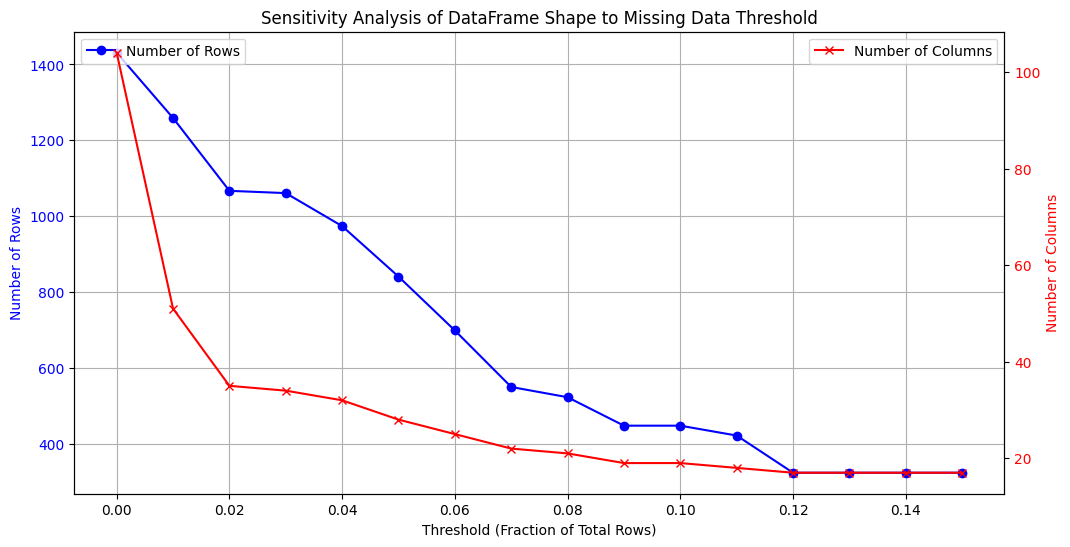

In [9]:
# Calculate the total number of rows in the DataFrame
total_rows = len(Na)

# Initialize lists to store results of shape (number of rows, number of columns) for each threshold
thresholds = []
num_rows_list = []
num_columns_list = []

# Perform sensitivity analysis for thresholds from 0% to 15%
for threshold in range(0, 16):
    threshold /= 100  # Convert to fraction
    thresholds.append(threshold)
    
    # Identify columns where non-zero (non-missing) data is less than the given threshold of total rows
    columns_to_remove = []
    rows_to_remove = set()

    for col in Na.columns:
        non_zero_count = len(Na[Na[col] != 0])
        if non_zero_count / total_rows < threshold:
            columns_to_remove.append(col)
            # Collect row indices where data in this column is not missing (not zero)
            rows_to_remove.update(Na.index[Na[col] != 0].tolist())

    # Remove the identified columns and rows
    temp_df = Na.drop(columns=columns_to_remove)
    temp_df.drop(index=list(rows_to_remove), inplace=True)
    
    # Store the shape of the DataFrame after filtering and pruning
    num_rows, num_columns = temp_df.shape
    num_rows_list.append(num_rows)
    num_columns_list.append(num_columns)

# Create a plot with dual y-axes
fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot for Number of Rows on the left y-axis
ax1.plot(thresholds, num_rows_list, label='Number of Rows', marker='o', color='b')
ax1.set_xlabel('Threshold (Fraction of Total Rows)')
ax1.set_ylabel('Number of Rows', color='b')
ax1.tick_params(axis='y', labelcolor='b')
ax1.legend(loc='upper left')
ax1.grid(True)

# Create a second y-axis to plot Number of Columns
ax2 = ax1.twinx()
ax2.plot(thresholds, num_columns_list, label='Number of Columns', marker='x', color='r')
ax2.set_ylabel('Number of Columns', color='r')
ax2.tick_params(axis='y', labelcolor='r')
ax2.legend(loc='upper right')

# Title for the plot
plt.title('Sensitivity Analysis of DataFrame Shape to Missing Data Threshold')

plt.show()

In [10]:
# Identify columns where non-zero (non-missing) data is less than 10% of total rows
columns_to_remove = []
rows_to_remove = set()

for col in Na.columns:
    non_zero_count = len(Na[Na[col] != 0])
    if non_zero_count / total_rows < 0.02:
        columns_to_remove.append(col)
        # Collect row indices where data in this column is not missing (not zero)
        rows_to_remove.update(Na.index[Na[col] != 0].tolist())

# Remove the identified columns and rows
filtered_Na = Na.drop(columns=columns_to_remove)
filtered_Na.drop(index=list(rows_to_remove), inplace=True)

filtered_Na.shape

(1067, 35)

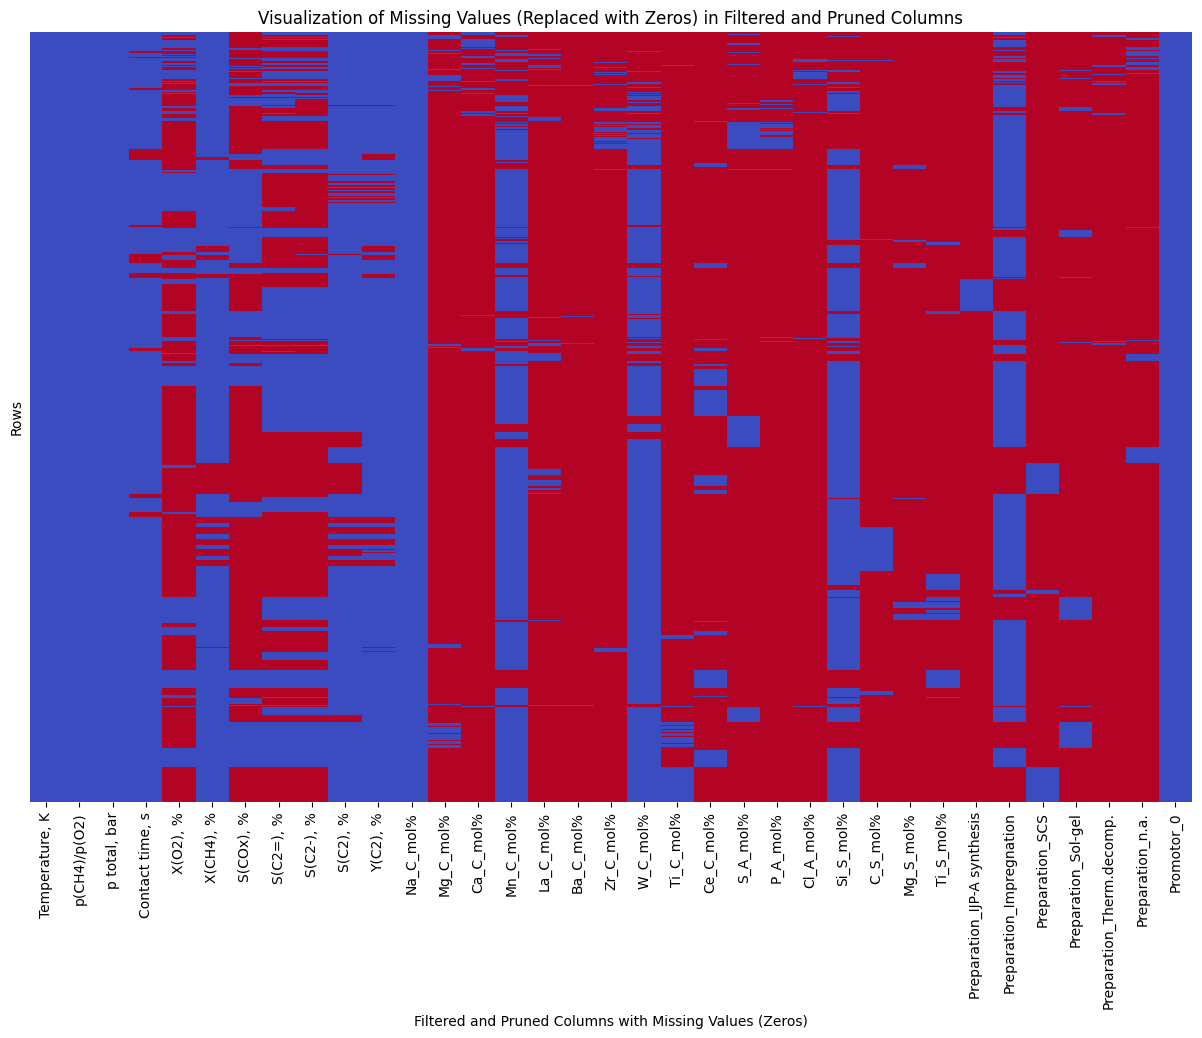

In [11]:
visualization_pruned_df = filtered_Na.eq(0).astype(int)

plt.figure(figsize=(15, 10))
sns.heatmap(visualization_pruned_df, cmap='coolwarm', cbar=False, yticklabels=False)
plt.title("Visualization of Missing Values (Replaced with Zeros) in Filtered and Pruned Columns")
plt.xlabel("Filtered and Pruned Columns with Missing Values (Zeros)")
plt.ylabel("Rows")
plt.show()

In [12]:
# Calculate 'Y(C2), %' where it's missing (NaN or 0) using 'S(C2), %' and 'X(CH4), %'
filtered_Na.loc[filtered_Na['Y(C2), %'] == 0, 'Y(C2), %'] = \
    filtered_Na['S(C2), %'] * filtered_Na['X(CH4), %']/100

# Remove rows where 'Y(C2), %' has missing values (reduced to zeros)
filtered_Na = filtered_Na[filtered_Na['Y(C2), %'] != 0]

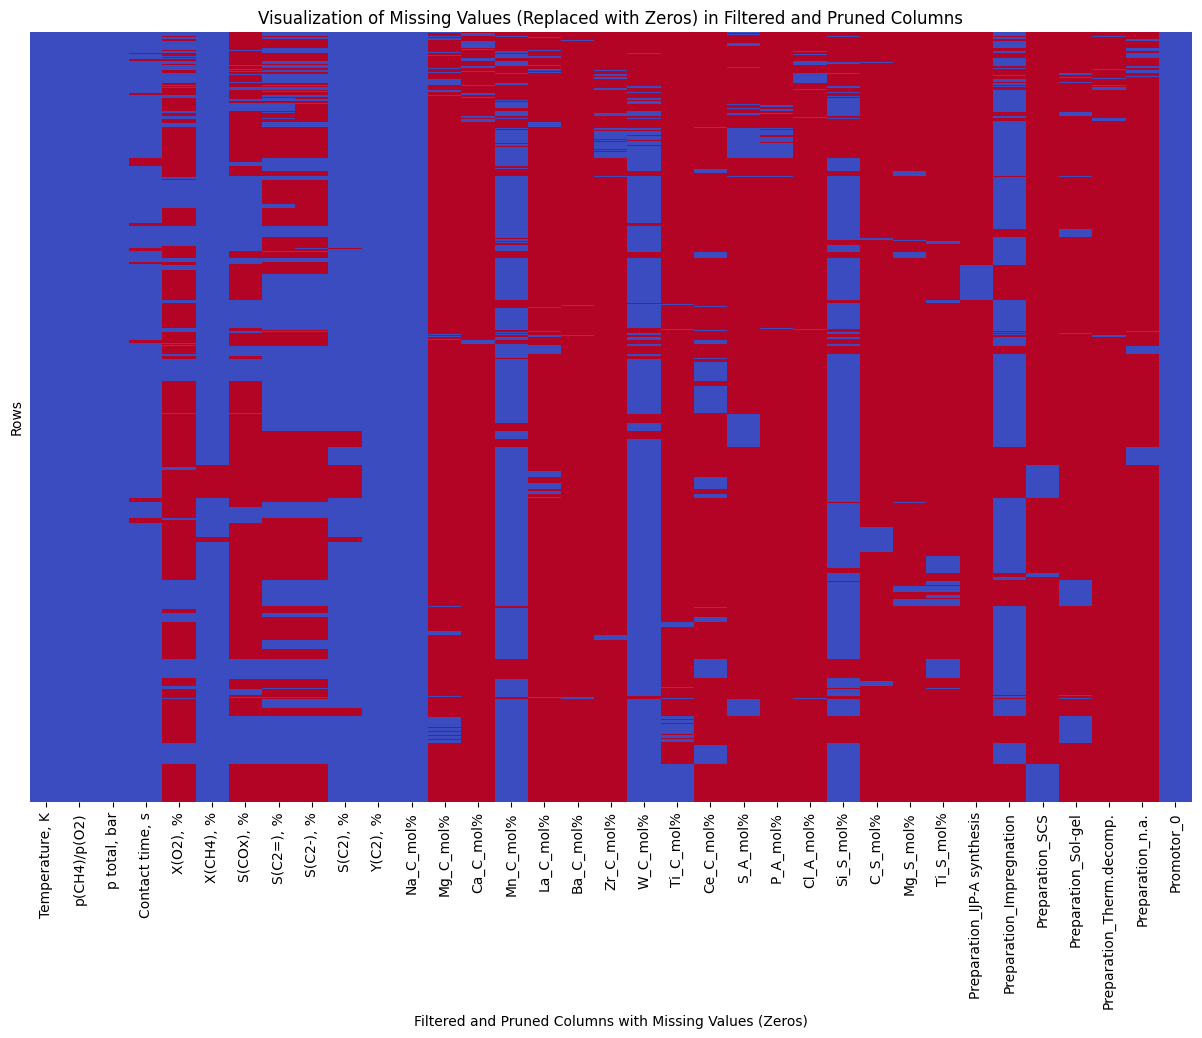

In [13]:
visualization_pruned_df = filtered_Na.eq(0).astype(int)

plt.figure(figsize=(15, 10))
sns.heatmap(visualization_pruned_df, cmap='coolwarm', cbar=False, yticklabels=False)
plt.title("Visualization of Missing Values (Replaced with Zeros) in Filtered and Pruned Columns")
plt.xlabel("Filtered and Pruned Columns with Missing Values (Zeros)")
plt.ylabel("Rows")
plt.show()

c:\Users\OJH\anaconda3\envs\analysis\lib\site-packages\seaborn\matrix.py:260: FutureWarning: Format strings passed to MaskedConstant are ignored, but in future may error or produce different behavior
  annotation = ("{:" + self.fmt + "}").format(val)


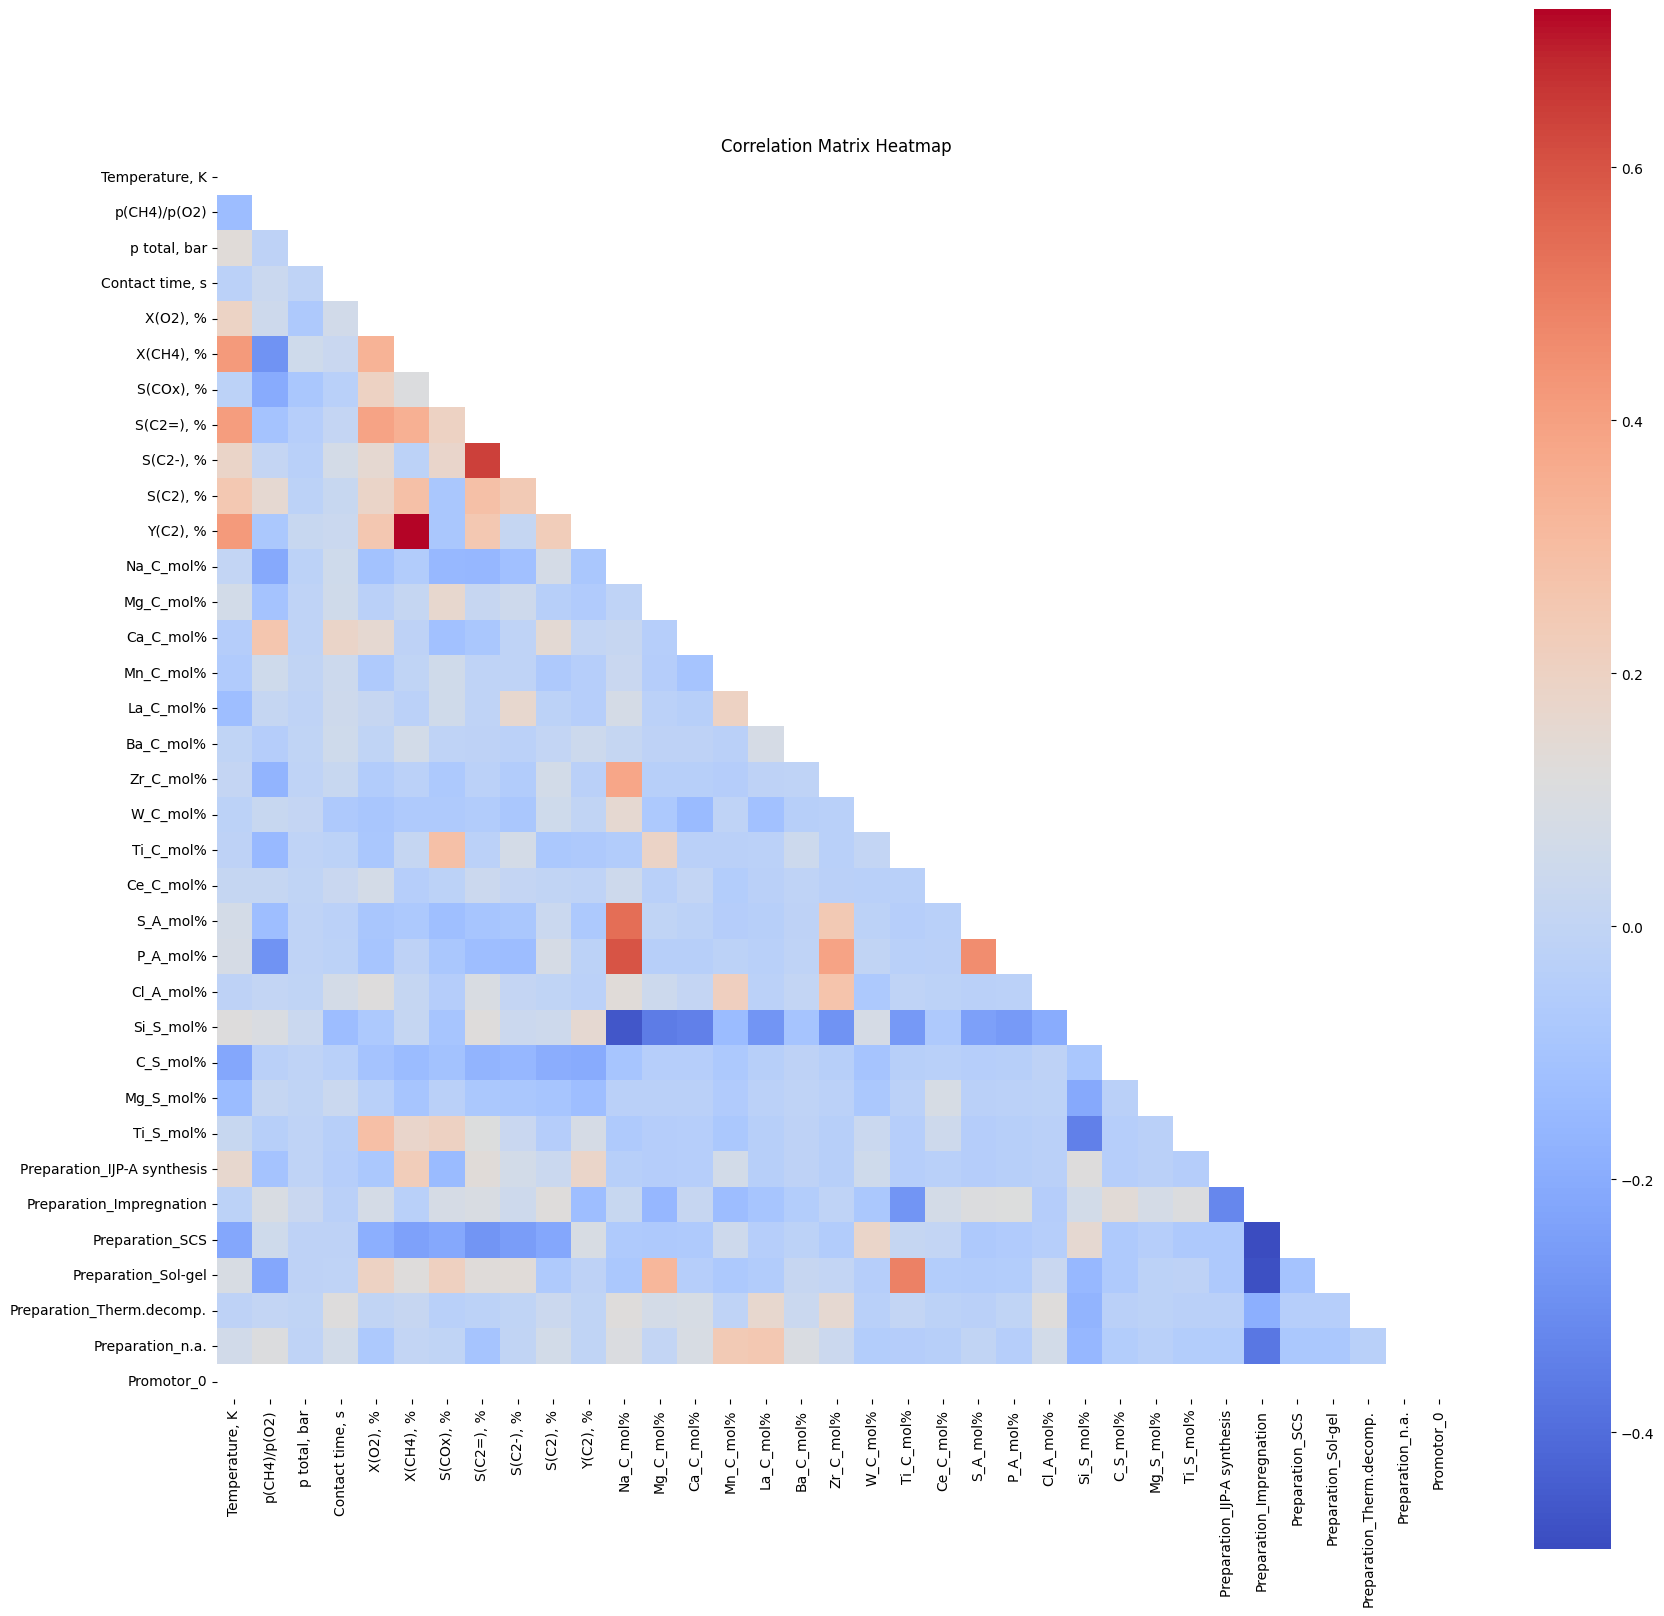

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the correlation matrix
correlation_matrix = filtered_Na.corr()

# Generate a mask for the upper triangle
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))

# Set up the matplotlib figure
plt.figure(figsize=(20, 20))

# Draw the heatmap with the mask and correct aspect ratio
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', square=True, mask=mask)

# Add title
plt.title('Correlation Matrix Heatmap')

plt.show()

In [15]:
# Find pairs of features with high absolute correlation
threshold = 0.4  # You can change the threshold value as needed
high_correlation_pairs = {}

# Iterate over the correlation matrix to find high correlation pairs
for column in correlation_matrix.columns:
    for index in correlation_matrix.index:
        if index == column:
            continue  # Skip the diagonal elements
        correlation_value = correlation_matrix.loc[index, column]
        if abs(correlation_value) > threshold:
            pair = f"{index} and {column}"
            high_correlation_pairs[pair] = correlation_value

high_correlation_pairs

{'X(CH4), % and Temperature, K': 0.4175404133504119,
 'S(C2=), % and Temperature, K': 0.4070684137286886,
 'Y(C2), % and Temperature, K': 0.4205977464075462,
 'Temperature, K and X(CH4), %': 0.4175404133504119,
 'Y(C2), % and X(CH4), %': 0.7250671610407745,
 'Temperature, K and S(C2=), %': 0.4070684137286886,
 'S(C2-), % and S(C2=), %': 0.6402671210995635,
 'S(C2=), % and S(C2-), %': 0.6402671210995635,
 'Temperature, K and Y(C2), %': 0.4205977464075462,
 'X(CH4), % and Y(C2), %': 0.7250671610407745,
 'S_A_mol% and Na_C_mol%': 0.5375549178790394,
 'P_A_mol% and Na_C_mol%': 0.5985418058311036,
 'Si_S_mol% and Na_C_mol%': -0.46175128924550424,
 'Preparation_Sol-gel and Ti_C_mol%': 0.4916997717681067,
 'Na_C_mol% and S_A_mol%': 0.5375549178790394,
 'P_A_mol% and S_A_mol%': 0.4544527843993656,
 'Na_C_mol% and P_A_mol%': 0.5985418058311036,
 'S_A_mol% and P_A_mol%': 0.4544527843993656,
 'Na_C_mol% and Si_S_mol%': -0.46175128924550424,
 'Preparation_SCS and Preparation_Impregnation': -0.4923

EDA (Exploratory data analysis)

       Temperature, K  p(CH4)/p(O2)  p total, bar  Contact time, s  \
count      985.000000    985.000000    985.000000       985.000000   
mean      1048.093401      4.108629      1.024873         0.336721   
std         59.605183      2.217112      0.559345         1.382283   
min        723.000000      0.300000      0.200000         0.000000   
25%       1013.000000      3.000000      1.000000         0.060000   
50%       1069.000000      4.000000      1.000000         0.160000   
75%       1073.000000      5.000000      1.000000         0.320000   
max       1198.000000     21.000000     10.000000        38.400000   

         X(O2), %   X(CH4), %   S(COx), %   S(C2=), %   S(C2-), %    S(C2), %  \
count  985.000000  985.000000  985.000000  985.000000  985.000000  985.000000   
mean    22.580914   19.466294   15.355939   15.352284   10.428426   51.013909   
std     39.115251   12.517830   23.510517   18.228860   13.609227   22.649718   
min      0.000000    0.000000    0.000000    

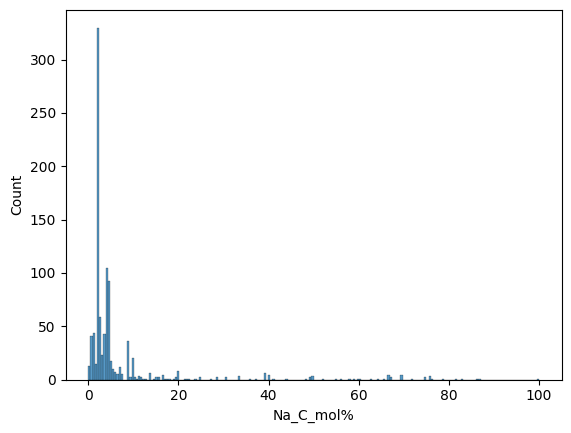

In [16]:
# 기초 통계량 확인
print(filtered_Na.describe())

# 결측치 확인
print(filtered_Na.isnull().sum())

# 히스토그램
sns.histplot(filtered_Na['Na_C_mol%'])
plt.show()

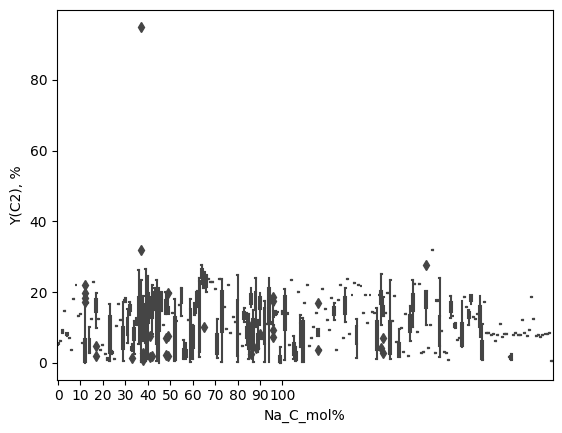

In [17]:
sns.boxplot(x='Na_C_mol%', y='Y(C2), %', data=filtered_Na)
# X 축 눈금 설정: 0부터 100까지 10단위
plt.xticks(ticks=range(0, 101, 10), labels=[str(i) for i in range(0, 101, 10)])

plt.show()

c:\Users\OJH\anaconda3\envs\analysis\lib\site-packages\seaborn\matrix.py:260: FutureWarning: Format strings passed to MaskedConstant are ignored, but in future may error or produce different behavior
  annotation = ("{:" + self.fmt + "}").format(val)


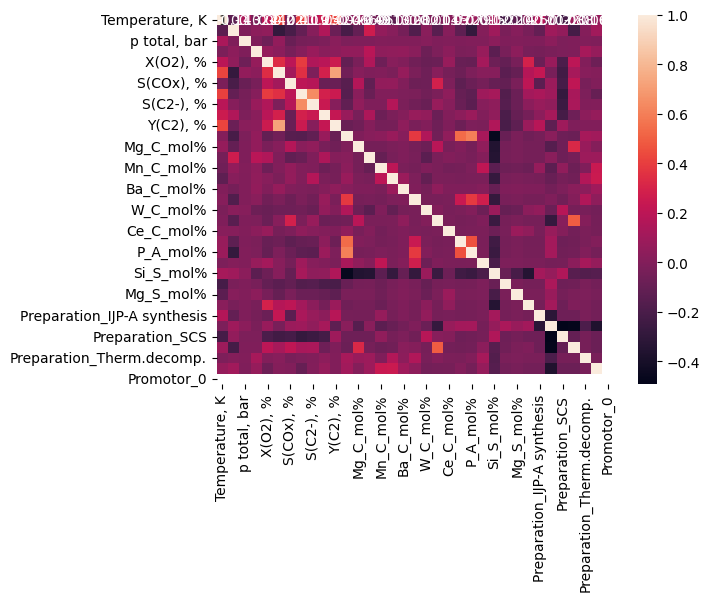

In [18]:
# 상관 관계 분석
correlation_matrix = filtered_Na.corr()
sns.heatmap(correlation_matrix, annot=True)
plt.show()

In [20]:
# Z-score를 이용한 이상치 탐지
from scipy import stats
import numpy as np

z_scores = np.abs(stats.zscore(filtered_Na['Y(C2), %']))
outliers_values_z_score = filtered_Na['Y(C2), %'][np.where(z_scores > 3)[0]]

print("Outliers values detected via Z-score:", outliers_values_z_score)

KeyError: "None of [Int64Index([277], dtype='int64')] are in the [index]"

In [21]:
Q1 = filtered_Na['Y(C2), %'].quantile(0.25)
Q3 = filtered_Na['Y(C2), %'].quantile(0.75)
IQR = Q3 - Q1

outliers_iqr = filtered_Na[(filtered_Na['Y(C2), %'] < (Q1 - 1.5 * IQR)) | (filtered_Na['Y(C2), %'] > (Q3 + 1.5 * IQR))].index
outliers_values_iqr = filtered_Na['Y(C2), %'][outliers_iqr]

print("Outliers values detected via IQR:", outliers_values_iqr)

Outliers values detected via IQR: 477    95.0
Name: Y(C2), %, dtype: float64


In [22]:
# Z-score 기반 이상치 제거
filtered_Na = filtered_Na[(z_scores <= 3)]

# IQR 기반 이상치 제거
filtered_Na = filtered_Na[~filtered_Na.index.isin(outliers_iqr)]

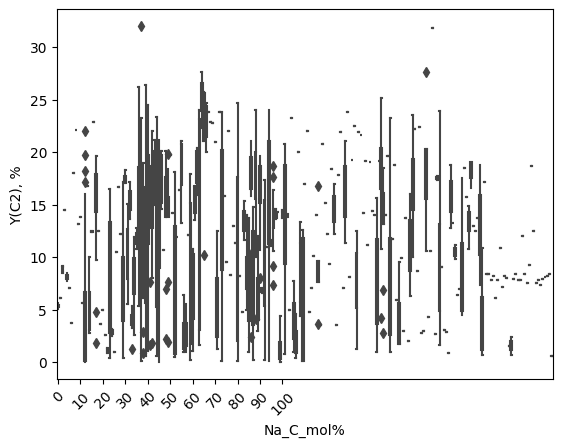

<Figure size 1000x600 with 0 Axes>

In [23]:
# Boxplot 생성
sns.boxplot(x='Na_C_mol%', y='Y(C2), %', data=filtered_Na)

# X 축 눈금 설정: 0부터 100까지 10단위
plt.xticks(ticks=range(0, 101, 10), labels=[str(i) for i in range(0, 101, 10)])
plt.xticks(rotation=45)
plt.figure(figsize=(10, 6))

plt.draw()

c:\Users\OJH\anaconda3\envs\analysis\lib\site-packages\seaborn\matrix.py:260: FutureWarning: Format strings passed to MaskedConstant are ignored, but in future may error or produce different behavior
  annotation = ("{:" + self.fmt + "}").format(val)


<Axes: >

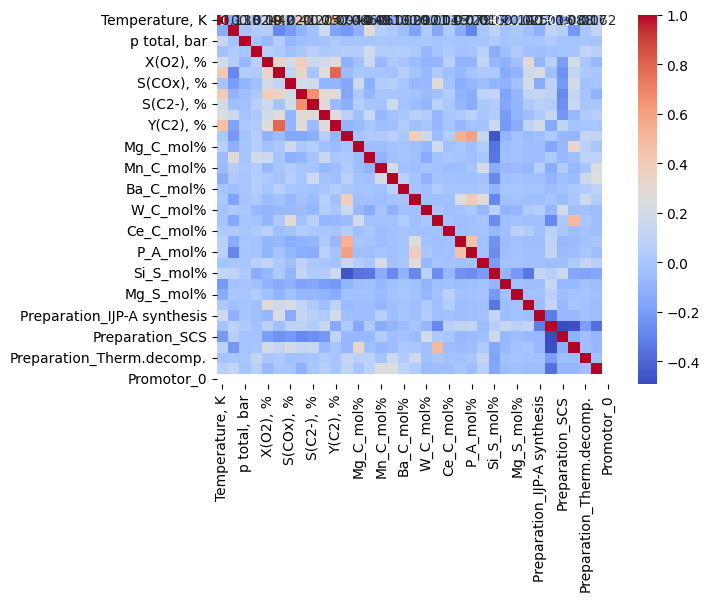

In [24]:
sns.heatmap(filtered_Na.corr(), annot=True, cmap='coolwarm')

<Axes: xlabel='Na_C_mol%', ylabel='Count'>

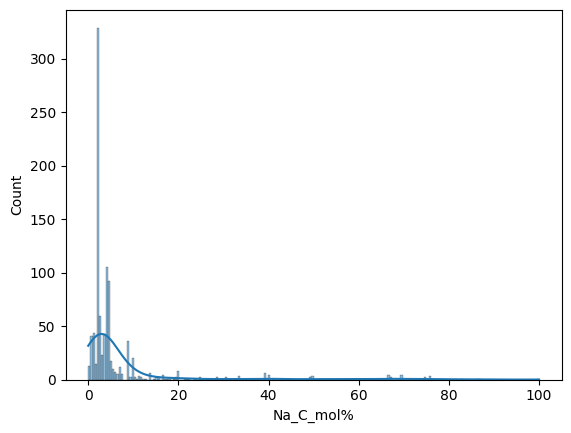

In [25]:
sns.histplot(data=filtered_Na, x='Na_C_mol%', kde=True)

<Axes: xlabel='Temperature, K', ylabel='Count'>

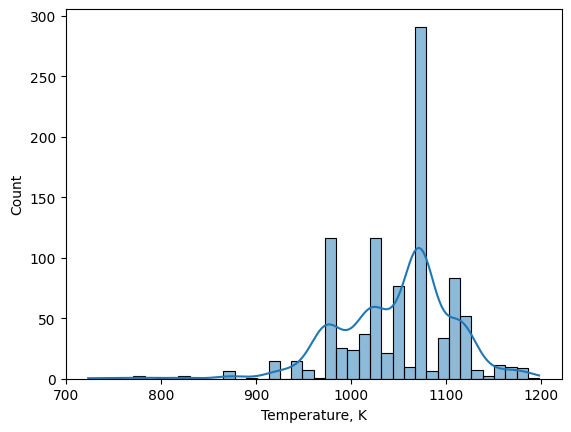

In [26]:
sns.histplot(data=filtered_Na, x='Temperature, K', kde=True)

<Axes: xlabel='p(CH4)/p(O2)', ylabel='Count'>

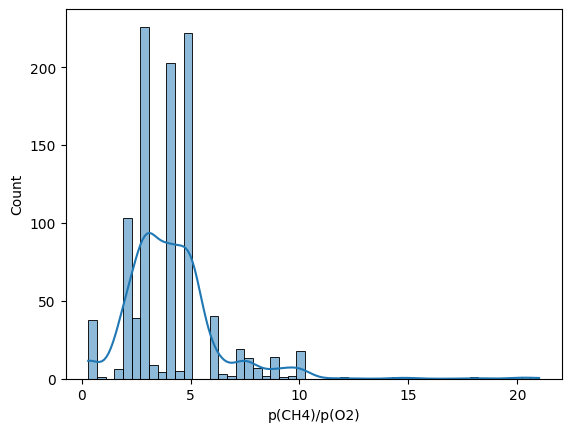

In [27]:
sns.histplot(data=filtered_Na, x='p(CH4)/p(O2)', kde=True)

<Axes: xlabel='p total, bar', ylabel='Count'>

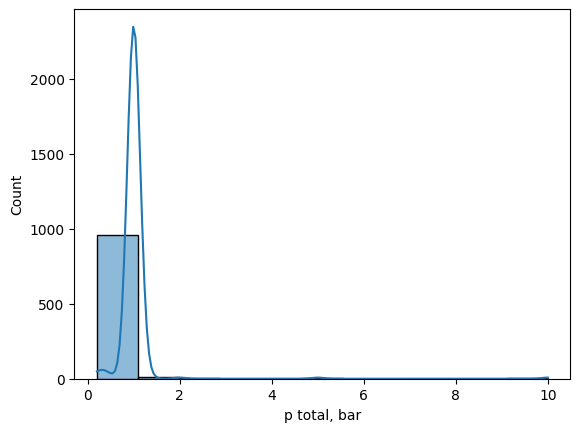

In [28]:
sns.histplot(data=filtered_Na, x='p total, bar', kde=True)

ML (Machine Learning)

In [66]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
from skopt import BayesSearchCV
from skopt.space import Real, Categorical, Integer
import warnings
from bayes_opt import BayesianOptimization
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.model_selection import cross_val_score
import numpy as np

column_names = filtered_Na.columns.tolist()
column_names

input_columns = [col for col in column_names if col not in ['X(O2), %', 'X(CH4), %', 'S(C2=), %', 'S(C2-), %', 'S(C2), %', 'Y(C2), %']]
output_column = 'Y(C2), %'

input_columns

from sklearn.model_selection import train_test_split

X = filtered_Na[input_columns]
y = filtered_Na[output_column]

# Split the data into training, testing, and validation sets (60%, 20%, 20%)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=42)
X_test, X_val, y_test, y_val = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

In [67]:
# Initialize a dictionary to store the best parameters for each model
best_params = {}

# Linear Regression
def optimize_lr(fit_intercept):
    fit_intercept = bool(round(fit_intercept))
    model = LinearRegression(fit_intercept=fit_intercept)
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)
    return -mean_squared_error(y_test, predictions)

optimizer_lr = BayesianOptimization(f=optimize_lr, pbounds={"fit_intercept": (0, 1)}, random_state=42, allow_duplicate_points=True)
optimizer_lr.maximize(init_points=20, n_iter=100)
best_params['Linear Regression'] = optimizer_lr.max['params']

# Decision Tree Regressor
def optimize_dtr(max_depth, min_samples_split):
    max_depth = int(round(max_depth))
    min_samples_split = int(round(min_samples_split))
    model = DecisionTreeRegressor(max_depth=max_depth, min_samples_split=min_samples_split)
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)
    return -mean_squared_error(y_test, predictions)

optimizer_dtr = BayesianOptimization(f=optimize_dtr, pbounds={"max_depth": (1, 32), "min_samples_split": (2, 10)}, random_state=42)
optimizer_dtr.maximize(init_points=20, n_iter=100)
best_params['Decision Tree Regressor'] = optimizer_dtr.max['params']

# K-NN
def optimize_knn(n_neighbors, p):
    model = KNeighborsRegressor(n_neighbors=int(n_neighbors), p=p)
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)
    return -mean_squared_error(y_test, predictions)

optimizer_knn = BayesianOptimization(f=optimize_knn, pbounds={"n_neighbors": (1, 20), "p": (1, 2)}, random_state=42)
optimizer_knn.maximize(init_points=20, n_iter=100)
best_params['K-NN'] = optimizer_knn.max['params']

# SVR
def optimize_svr(C, epsilon):
    model = SVR(C=C, epsilon=epsilon)
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)
    return -mean_squared_error(y_test, predictions)

optimizer_svr = BayesianOptimization(f=optimize_svr, pbounds={"C": (1, 100), "epsilon": (0.01, 0.1)}, random_state=42)
optimizer_svr.maximize(init_points=20, n_iter=100)
best_params['SVR'] = optimizer_svr.max['params']

# GPR
def optimize_gpr(alpha):
    model = GaussianProcessRegressor(alpha=alpha)
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)
    return -mean_squared_error(y_test, predictions)

optimizer_gpr = BayesianOptimization(f=optimize_gpr, pbounds={"alpha": (0.01, 1)}, random_state=42, allow_duplicate_points=True)
optimizer_gpr.maximize(init_points=20, n_iter=100)
best_params['GaussianProcessRegressor'] = optimizer_gpr.max['params']

# RFR
def optimize_rfr(n_estimators, max_depth):
    model = RandomForestRegressor(n_estimators=int(n_estimators), max_depth=int(max_depth))
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)
    return -mean_squared_error(y_test, predictions)

optimizer_rfr = BayesianOptimization(f=optimize_rfr, pbounds={"n_estimators": (50, 200), "max_depth": (5, 50)}, random_state=42)
optimizer_rfr.maximize(init_points=20, n_iter=100)
best_params['RandomForestRegressor'] = optimizer_rfr.max['params']

# XGBoost
def optimize_xgb(learning_rate, n_estimators):
    model = XGBRegressor(learning_rate=learning_rate, n_estimators=int(n_estimators))
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)
    return -mean_squared_error(y_test, predictions)

optimizer_xgb = BayesianOptimization(f=optimize_xgb, pbounds={"learning_rate": (0.01, 0.3), "n_estimators": (50, 200)}, random_state=42)
optimizer_xgb.maximize(init_points=20, n_iter=100)
best_params['XGBRegressor'] = optimizer_xgb.max['params']

# MLP
def optimize_mlp(alpha, learning_rate_init):
    model = MLPRegressor(alpha=alpha, learning_rate_init=learning_rate_init, max_iter=1000)
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)
    return -mean_squared_error(y_test, predictions)

optimizer_mlp = BayesianOptimization(f=optimize_mlp, pbounds={"alpha": (0.0001, 0.1), "learning_rate_init": (0.001, 0.1)}, random_state=42)
optimizer_mlp.maximize(init_points=20, n_iter=100)
best_params['MLPRegressor'] = optimizer_mlp.max['params']

|   iter    |  target   | fit_in... |
-------------------------------------
| 1         | -38.45    | 0.3745    |
| 2         | -38.45    | 0.9507    |
| 3         | -38.45    | 0.732     |
| 4         | -38.45    | 0.5987    |
| 5         | -38.45    | 0.156     |
| 6         | -38.45    | 0.156     |
| 7         | -38.45    | 0.05808   |
| 8         | -38.45    | 0.8662    |
| 9         | -38.45    | 0.6011    |
| 10        | -38.45    | 0.7081    |
| 11        | -38.45    | 0.02058   |
| 12        | -38.45    | 0.9699    |
| 13        | -38.45    | 0.8324    |
| 14        | -38.45    | 0.2123    |
| 15        | -38.45    | 0.1818    |
| 16        | -38.45    | 0.1834    |
| 17        | -38.45    | 0.3042    |
| 18        | -38.45    | 0.5248    |
| 19        | -38.45    | 0.4319    |
| 20        | -38.45    | 0.2912    |
| 21        | -38.45    | 0.6625    |
| 22        | -38.45    | 0.5534    |
| 23        | -38.45    | 0.9999    |
| 24        | -38.45    | 0.7905    |
| 25        

In [68]:
# Initialize a dictionary to store the validation MSE for each model
validation_mse = {}

# Linear Regression
best_lr_params = best_params['Linear Regression']
best_lr_params['fit_intercept'] = bool(round(best_lr_params['fit_intercept']))
lr_model = LinearRegression(**best_lr_params)
lr_model.fit(X_train, y_train)
lr_predictions = lr_model.predict(X_val)
lr_mse = mean_squared_error(y_val, lr_predictions)
validation_mse['Linear Regression'] = lr_mse

# K-NN
best_knn_params = best_params['K-NN']
best_knn_params['n_neighbors'] = int(round(best_knn_params['n_neighbors']))
knn_model = KNeighborsRegressor(**best_knn_params)
knn_model.fit(X_train, y_train)
knn_predictions = knn_model.predict(X_val)
knn_mse = mean_squared_error(y_val, knn_predictions)
validation_mse['K-NN'] = knn_mse

# SVR
best_svr_params = best_params['SVR']
svr_model = SVR(**best_svr_params)
svr_model.fit(X_train, y_train)
svr_predictions = svr_model.predict(X_val)
svr_mse = mean_squared_error(y_val, svr_predictions)
validation_mse['SVR'] = svr_mse

# GPR
best_gpr_params = best_params['GaussianProcessRegressor']
gpr_model = GaussianProcessRegressor(**best_gpr_params)
gpr_model.fit(X_train, y_train)
gpr_predictions = gpr_model.predict(X_val)
gpr_mse = mean_squared_error(y_val, gpr_predictions)
validation_mse['GaussianProcessRegressor'] = gpr_mse

# RFR
best_rfr_params = best_params['RandomForestRegressor']
best_rfr_params['max_depth'] = int(round(best_rfr_params['max_depth']))
best_rfr_params['n_estimators'] = int(round(best_rfr_params['n_estimators']))
rfr_model = RandomForestRegressor(**best_rfr_params)
rfr_model.fit(X_train, y_train)
rfr_predictions = rfr_model.predict(X_val)
rfr_mse = mean_squared_error(y_val, rfr_predictions)
validation_mse['RandomForestRegressor'] = rfr_mse

# XGBoost
best_xgb_params = best_params['XGBRegressor']
best_xgb_params['n_estimators'] = int(round(best_xgb_params['n_estimators']))
xgb_model = XGBRegressor(**best_xgb_params)
xgb_model.fit(X_train, y_train)
xgb_predictions = xgb_model.predict(X_val)
xgb_mse = mean_squared_error(y_val, xgb_predictions)
validation_mse['XGBRegressor'] = xgb_mse

# MLP
best_mlp_params = best_params['MLPRegressor']
mlp_model = MLPRegressor(**best_mlp_params)
mlp_model.fit(X_train, y_train)
mlp_predictions = mlp_model.predict(X_val)
mlp_mse = mean_squared_error(y_val, mlp_predictions)
validation_mse['MLPRegressor'] = mlp_mse

# Initialize dictionary to hold predictions from each model for Bayesian Model Averaging
predictions_dict = {}

# Get predictions from each trained model and store in the dictionary
predictions_dict['Linear Regression'] = lr_model.predict(X_val)
predictions_dict['K-NN'] = knn_model.predict(X_val)
predictions_dict['SVR'] = svr_model.predict(X_val)
predictions_dict['GaussianProcessRegressor'] = gpr_model.predict(X_val)
predictions_dict['RandomForestRegressor'] = rfr_model.predict(X_val)
predictions_dict['XGBRegressor'] = xgb_model.predict(X_val)
predictions_dict['MLPRegressor'] = mlp_model.predict(X_val)

c:\Users\OJH\anaconda3\envs\analysis\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


In [69]:
print([lr_mse, knn_mse, svr_mse, gpr_mse, rfr_mse, xgb_mse, mlp_mse])

[72.55036217763461, 25.24318126388584, 35.133532203189155, 121.28976087062513, 15.314624913435905, 15.704761310670905, 36.54939078263998]


In [ ]:
from sklearn.ensemble import VotingRegressor

# Initialize the models with best parameters
lr_model = LinearRegression(**best_params['Linear Regression'])
knn_model = KNeighborsRegressor(**best_params['K-NN'])
svr_model = SVR(**best_params['SVR'])
gpr_model = GaussianProcessRegressor(**best_params['GaussianProcessRegressor'])
rfr_model = RandomForestRegressor(**best_params['RandomForestRegressor'])
xgb_model = XGBRegressor(**best_params['XGBRegressor'])
mlp_model = MLPRegressor(**best_params['MLPRegressor'])

# Create a VotingRegressor instance
voting_reg = VotingRegressor(estimators=[
    ('lr', lr_model), 
    ('knn', knn_model), 
    ('svr', svr_model),
    ('gpr', gpr_model), 
    ('rfr', rfr_model), 
    ('xgb', xgb_model),
    ('mlp', mlp_model)
])

# Fit the ensemble model
voting_reg.fit(X_train, y_train)

# Make predictions on validation set
voting_predictions = voting_reg.predict(X_val)

# Calculate the MSE
voting_mse = mean_squared_error(y_val, voting_predictions)

# Add to the validation MSE dictionary
validation_mse['VotingRegressor'] = voting_mse

print(f"Voting Regressor MSE: {voting_mse}")

In [ ]:
from sklearn.ensemble import StackingRegressor
from sklearn.linear_model import LinearRegression

# Initialize the first-level base models with the optimized hyperparameters
lr_model = LinearRegression(**best_params['Linear Regression'])
knn_model = KNeighborsRegressor(**best_params['K-NN'])
svr_model = SVR(**best_params['SVR'])
gpr_model = GaussianProcessRegressor(**best_params['GaussianProcessRegressor'])
rfr_model = RandomForestRegressor(**best_params['RandomForestRegressor'])
xgb_model = XGBRegressor(**best_params['XGBRegressor'])
mlp_model = MLPRegressor(**best_params['MLPRegressor'])

# Initialize the Stacking Regressor
stacking_regressor = StackingRegressor(
    estimators=[
        ('lr', lr_model),
        ('knn', knn_model),
        ('svr', svr_model),
        ('gpr', gpr_model),
        ('rfr', rfr_model),
        ('xgb', xgb_model),
        ('mlp', mlp_model)
    ],
    final_estimator=LinearRegression()
)

# Fit the ensemble model
stacking_regressor.fit(X_train, y_train)

# Make predictions on the validation set
stacking_predictions = stacking_regressor.predict(X_val)

# Calculate the MSE
stacking_mse = mean_squared_error(y_val, stacking_predictions)

print(f"Stacking Regressor MSE: {stacking_mse}")

In [ ]:
import pymc3 as pm

# Check the length of y_val
print("Length of y_val:", len(y_val))

# Check the length of one set of predictions (assuming all have the same length)
print("Length of a set of predictions:", len(predictions_dict['Linear Regression']))

# Actual target values: Replace these with your actual target values
y_val = y_val

# Number of models
num_models = len(predictions_dict)

# Initialize Bayesian Model
with pm.Model() as model:
    # Prior for each model's weight
    w = pm.Dirichlet('w', a=np.ones(num_models))

    # Expected value calculation based on model weights
    mu = pm.math.dot(w, np.array([predictions_dict[model_name] for model_name in predictions_dict.keys()]))

    # Likelihood
    y_obs = pm.Normal('y_obs', mu=mu, sd=1, observed=y_val)

    # Run MCMC
    trace = pm.sample(2000, tune=1000)

# Extract trace for the model weights
trace_w = trace['w']

# Calculate Bayesian Model Average
bma_prediction = np.dot(trace_w.mean(axis=0), [predictions_dict[model_name] for model_name in predictions_dict.keys()])

In [ ]:

# Initialize an empty list to store MSE values
mse_values = []

# Initialize an empty list to store different percentage thresholds
thresholds = [0.0, 0.05, 0.1, 0.15]

for threshold in thresholds:
    # Identify columns where non-zero (non-missing) data is less than the threshold
    total_rows = len(filtered_Na)
    columns_to_remove = []
    rows_to_remove = set()

    for col in filtered_Na.columns:
        non_zero_count = len(filtered_Na[filtered_Na[col] != 0])
        if non_zero_count / total_rows < threshold:
            columns_to_remove.append(col)
            # Collect row indices where data in this column is not missing (not zero)
            rows_to_remove.update(filtered_Na.index[filtered_Na[col] != 0].tolist())

    # Remove the identified columns and rows
    reduced_Na = filtered_Na.drop(columns=columns_to_remove)
    reduced_Na.drop(index=list(rows_to_remove), inplace=True)

    # Prepare the data for ML models
    column_names = reduced_Na.columns.tolist()
    input_columns = [col for col in column_names if col not in ['X(O2), %', 'X(CH4), %', 'S(C2=), %', 'S(C2-), %', 'S(C2), %', 'Y(C2), %']]
    output_column = 'Y(C2), %'

    if output_column in reduced_Na.columns:
        X = reduced_Na[input_columns]
        y = reduced_Na[output_column]

        # Split the data into training and validation sets (80%, 20%)
        X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

        # Initialize models with fixed hyperparameters
        models = {
            'Linear Regression': LinearRegression(),
            'K-NN': KNeighborsRegressor(),
            'SVR': SVR(),
            'GPR': GaussianProcessRegressor(),
            'RFR': RandomForestRegressor(),
            'XGBoost': XGBRegressor(),
            'MLP Regressor': MLPRegressor(max_iter=500)
        }

        # Compute MSE for each model
        model_mse = {}
        for name, model in models.items():
            model.fit(X_train, y_train)
            predictions = model.predict(X_val)
            mse = mean_squared_error(y_val, predictions)
            model_mse[name] = mse

        mse_values.append(model_mse)

# Plotting
labels = list(models.keys())
linear_reg_mse = [x['Linear Regression'] for x in mse_values]
knn_mse = [x['K-NN'] for x in mse_values]
svr_mse = [x['SVR'] for x in mse_values]
gpr_mse = [x['GPR'] for x in mse_values]
rfr_mse = [x['RFR'] for x in mse_values]
xgb_mse = [x['XGBoost'] for x in mse_values]
mlp_mse = [x['MLP Regressor'] for x in mse_values]

x = np.arange(len(thresholds))
width = 0.1

fig, ax = plt.subplots(figsize=(15, 8))

rects1 = ax.bar(x - 3*width/2, linear_reg_mse, width, label='Linear Regression')
rects2 = ax.bar(x - width/2, knn_mse, width, label='K-NN')
rects3 = ax.bar(x + width/2, svr_mse, width, label='SVR')
rects4 = ax.bar(x + 3*width/2, gpr_mse, width, label='GPR')
rects5 = ax.bar(x + 5*width/2, rfr_mse, width, label='RFR')
rects6 = ax.bar(x + 7*width/2, xgb_mse, width, label='XGBoost')
rects7 = ax.bar(x + 9*width/2, mlp_mse, width, label='MLP Regressor')

ax.set_ylabel('MSE')
ax.set_title('MSE values by different models and thresholds')
ax.set_xticks(x)
ax.set_xticklabels([str(th*100) + "%" for th in thresholds])
ax.legend()

fig.tight_layout()
plt.show()